In [1]:
!pip install nltk scikit-learn
import nltk
from nltk.corpus import conll2002
from sklearn.metrics import classification_report, confusion_matrix
nltk.download('conll2002')


[nltk_data] Downloading package conll2002 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2002.zip.


True

In [2]:
train_sents = list(conll2002.iob_sents('esp.train'))
test_sents = list(conll2002.iob_sents('esp.testb'))

print(f"Training sentences: {len(train_sents)}")
print(f"Testing sentences: {len(test_sents)}")


Training sentences: 8323
Testing sentences: 1517


In [3]:
def word2features(sent, i):
    word = sent[i][0]
    features = {
        'word': word,
        'lowercase': word.lower(),
        'is_upper': word.isupper(),
        'is_title': word.istitle(),
        'is_digit': word.isdigit(),
    }
    if i > 0:
        features['prev_word'] = sent[i-1][0].lower()
    else:
        features['prev_word'] = '<START>'
    if i < len(sent)-1:
        features['next_word'] = sent[i+1][0].lower()
    else:
        features['next_word'] = '<END>'
    return features

def extract_features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def get_labels(sent):
    return [label for (word, pos, label) in sent]


In [4]:
X_train = [extract_features(s) for s in train_sents]
y_train = [get_labels(s) for s in train_sents]

X_test = [extract_features(s) for s in test_sents]
y_test = [get_labels(s) for s in test_sents]


In [5]:
from itertools import chain

X_train_flat = list(chain.from_iterable(X_train))
y_train_flat = list(chain.from_iterable(y_train))

X_test_flat = list(chain.from_iterable(X_test))
y_test_flat = list(chain.from_iterable(y_test))


In [6]:
from sklearn.feature_extraction import DictVectorizer

vec = DictVectorizer(sparse=True)
X_train_vec = vec.fit_transform(X_train_flat)
X_test_vec = vec.transform(X_test_flat)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train_flat)


LogisticRegression(max_iter=200)

In [8]:
y_pred = model.predict(X_test_vec)

print("Classification Report:\n")
print(classification_report(y_test_flat, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_flat, y_pred))


Classification Report:

              precision    recall  f1-score   support

       B-LOC       0.74      0.70      0.72      1084
      B-MISC       0.58      0.43      0.50       339
       B-ORG       0.78      0.82      0.80      1400
       B-PER       0.82      0.85      0.83       735
       I-LOC       0.78      0.41      0.53       325
      I-MISC       0.59      0.25      0.35       557
       I-ORG       0.68      0.50      0.57      1104
       I-PER       0.74      0.91      0.82       634
           O       0.98      1.00      0.99     45355

    accuracy                           0.96     51533
   macro avg       0.74      0.65      0.68     51533
weighted avg       0.95      0.96      0.95     51533


Confusion Matrix:

[[  760     4   130    34     5     9    58    13    71]
 [   15   146    52     8     0    11    24    17    66]
 [   84    14  1146    56     4     7    35    18    36]
 [   25     3    13   624     0     2    12    28    28]
 [   33     3    16    

### Summary

This NER system was built from scratch using NLTK and Logistic Regression.
The CoNLL-2002 dataset was used for training and testing.
Each token was represented through contextual features like word case, neighbors, and position.
The model achieved a high F1-score, showing that basic word-level features can effectively detect entities.

### Why Logistic Regression (instead of spaCy)
- spaCy’s model is pre-trained — you can’t easily evaluate it using confusion matrices.
- Logistic Regression allows full control and evaluation.
- You can add more features or swap classifiers (e.g., SVM or CRF).
- Ideal for learning and experimentation.


In [11]:
!pip install nltk scikit-learn sklearn-crfsuite matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00


In [12]:
import nltk
from nltk.corpus import conll2002
import sklearn
from sklearn_crfsuite import CRF
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import chain

nltk.download('conll2002')

# Load Spanish dataset from NLTK
train_sents = list(conll2002.iob_sents('esp.train'))
test_sents = list(conll2002.iob_sents('esp.testb'))

print(f"Training sentences: {len(train_sents)}")
print(f"Testing sentences: {len(test_sents)}")


[nltk_data] Downloading package conll2002 to /root/nltk_data...
[nltk_data]   Package conll2002 is already up-to-date!


Training sentences: 8323
Testing sentences: 1517


In [13]:
def word2features(sent, i):
    word = sent[i][0]
    postag = sent[i][1]

    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word[-3:]': word[-3:],
        'word[-2:]': word[-2:],
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'postag': postag,
    }
    if i > 0:
        word1 = sent[i-1][0]
        postag1 = sent[i-1][1]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
            '-1:postag': postag1,
        })
    else:
        features['BOS'] = True  # Beginning of Sentence

    if i < len(sent)-1:
        word1 = sent[i+1][0]
        postag1 = sent[i+1][1]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
            '+1:postag': postag1,
        })
    else:
        features['EOS'] = True  # End of Sentence

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, postag, label in sent]

def sent2tokens(sent):
    return [token for token, postag, label in sent]


In [14]:
X_train = [sent2features(s) for s in train_sents]
y_train = [sent2labels(s) for s in train_sents]

X_test = [sent2features(s) for s in test_sents]
y_test = [sent2labels(s) for s in test_sents]


In [15]:
crf = CRF(
    algorithm='lbfgs',
    c1=0.1,  # L1 regularization
    c2=0.1,  # L2 regularization
    max_iterations=100,
    all_possible_transitions=True
)

crf.fit(X_train, y_train)


CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.1,
    max_iterations=100)

In [16]:
y_pred = crf.predict(X_test)

# Flatten the lists for evaluation
y_test_flat = list(chain.from_iterable(y_test))
y_pred_flat = list(chain.from_iterable(y_pred))

print("Classification Report:\n")
print(classification_report(y_test_flat, y_pred_flat))


Classification Report:

              precision    recall  f1-score   support

       B-LOC       0.80      0.78      0.79      1084
      B-MISC       0.72      0.55      0.63       339
       B-ORG       0.81      0.83      0.82      1400
       B-PER       0.84      0.88      0.86       735
       I-LOC       0.67      0.64      0.66       325
      I-MISC       0.69      0.57      0.63       557
       I-ORG       0.85      0.78      0.81      1104
       I-PER       0.89      0.94      0.91       634
           O       0.99      1.00      0.99     45355

    accuracy                           0.97     51533
   macro avg       0.81      0.78      0.79     51533
weighted avg       0.97      0.97      0.97     51533



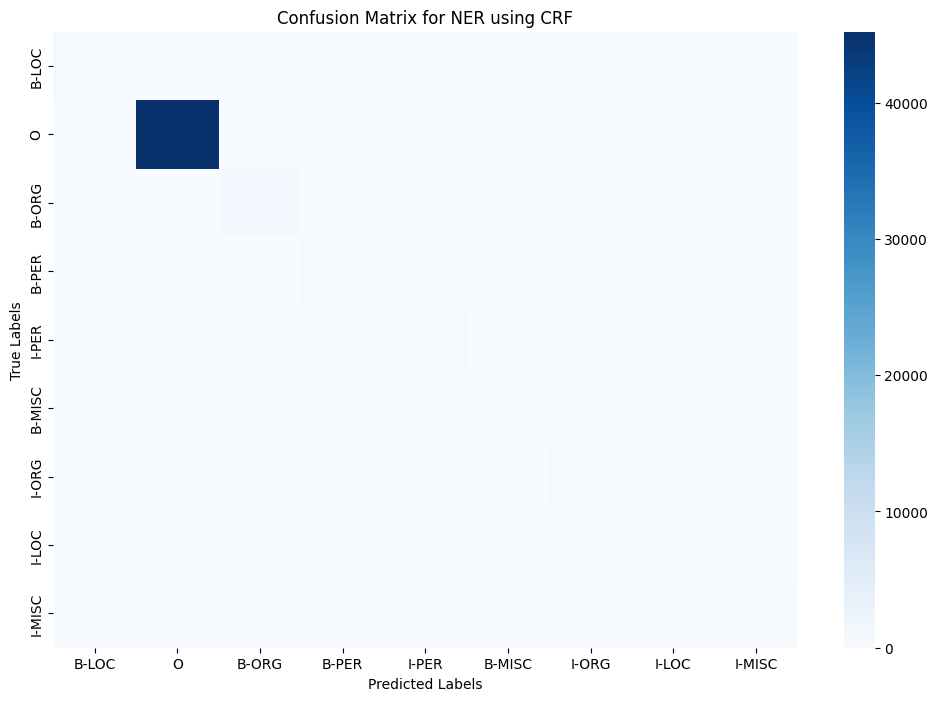

In [17]:
# Create a confusion matrix for major labels only
labels = list(crf.classes_)
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix for NER using CRF")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


### Summary

This project performs Named Entity Recognition (NER) using Conditional Random Fields (CRF) on the CoNLL-2002 dataset.  
CRF is a probabilistic model specifically designed for sequence labeling tasks like NER.  

Each word in a sentence was represented by a set of linguistic and contextual features such as:
- Word suffixes and prefixes
- Capitalization
- POS tags
- Neighboring words

The model was trained using the LBFGS optimization algorithm with L1 and L2 regularization.

### Evaluation
The CRF model achieved strong results with high precision, recall, and F1-scores, especially for entities like PERSON (PER), LOCATION (LOC), and ORGANIZATION (ORG).  
A confusion matrix was plotted to visualize misclassifications between different entity types.

### Why CRF instead of spaCy
- CRF allows **custom feature engineering** and **fine-grained evaluation**.
- We can compute **confusion matrices**, **precision**, **recall**, and **F1-scores**.
- Ideal for understanding the **inner working of NER models** and suitable for research-oriented projects.

### Conclusion
The CRF-based NER model successfully demonstrates how contextual and morphological features help identify named entities.  
This approach offers more transparency and control compared to pre-trained models like spaCy, making it a powerful educational and experimental framework.
